In [1]:
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt

In [2]:
cnn = tf.keras.models.load_model('trained_model.keras')

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    './New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [4]:
class_name = validation_set.class_names
print(class_name)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

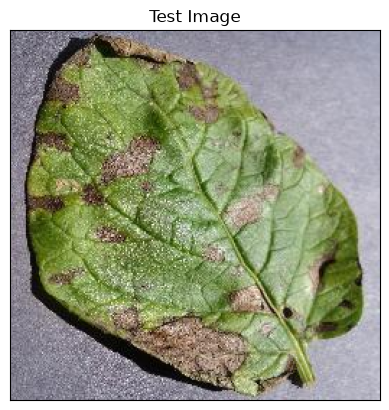

In [5]:
import cv2
image_path = 'test/test/PotatoEarlyBlight/PotatoEarlyBlight1.JPG'
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [6]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(256,256))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


In [7]:
print(predictions)

[[6.4808276e-20 6.9560629e-22 1.2884442e-26 3.6304011e-26 5.3914099e-30
  4.3034095e-23 2.0203296e-26 3.0590965e-20 5.3068735e-22 1.4579368e-22
  1.5031608e-30 2.9196472e-26 8.4059835e-24 2.9286532e-16 2.8901325e-30
  5.9994151e-27 1.9840999e-23 3.2638817e-33 7.9413499e-21 1.1327014e-26
  1.0000000e+00 5.2230794e-16 3.2146814e-23 8.9312921e-28 9.0739384e-30
  2.7875925e-20 3.1057674e-11 2.0417320e-23 1.5877874e-30 2.7396290e-18
  3.9506527e-18 8.4628271e-26 1.8454155e-17 1.1529743e-31 5.9843293e-27
  5.0787134e-29 3.2908361e-33 4.4173111e-22]]


In [8]:
result_index = np.argmax(predictions)
print(result_index)

20


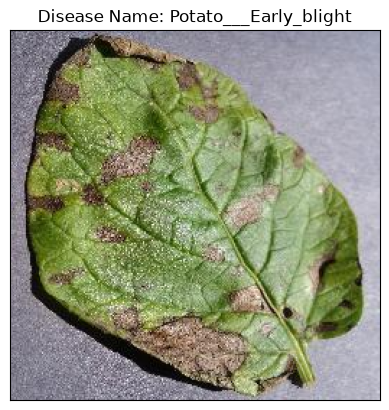

In [9]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()